In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/FallenTrees"

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/FallenTrees"

# Extensions / patterns to delete
extensions = (".yaml", ".yml", ".cache")

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(extensions) or "cache" in file.lower():
            file_path = os.path.join(root, file)
            try:
                os.remove(file_path)
                print(f"Deleted: {file_path}")
            except Exception as e:
                print(f"Error deleting {file_path}: {e}")

Deleted: /content/drive/MyDrive/FallenTrees/valid/labels.cache
Deleted: /content/drive/MyDrive/FallenTrees/train/labels.cache


In [ ]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
yaml_content = f"""
path: {dataset_path}
train: train/images
val: valid/images
test: test/images

names:
  0: fallen_trees
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created!")

data.yaml created!


In [ ]:
def check_dataset(path):
    for split in ["train", "valid", "test"]:
        img_path = os.path.join(path, split, "images")
        lbl_path = os.path.join(path, split, "labels")

        print(f"\nChecking {split}...")

        images = os.listdir(img_path)
        labels = os.listdir(lbl_path)

        print(f"Images: {len(images)}, Labels: {len(labels)}")

        missing = 0
        for img in images:
            txt = img.replace(".jpg", ".txt").replace(".png", ".txt")
            if txt not in labels:
                missing += 1

        print(f"Missing labels: {missing}")

check_dataset(dataset_path)


Checking train...
Images: 8500, Labels: 8500
Missing labels: 0

Checking valid...
Images: 982, Labels: 982
Missing labels: 0

Checking test...
Images: 1632, Labels: 1632
Missing labels: 0


In [ ]:
def bbox_to_polygon(line):
    parts = list(map(float, line.strip().split()))
    cls, x, y, w, h = parts

    # Convert YOLO bbox → 4 corner polygon
    x1 = x - w/2
    y1 = y - h/2
    x2 = x + w/2
    y2 = y - h/2
    x3 = x + w/2
    y3 = y + h/2
    x4 = x - w/2
    y4 = y + h/2

    return f"{int(cls)} {x1} {y1} {x2} {y2} {x3} {y3} {x4} {y4}"

In [ ]:
import os

base_path = "/content/drive/MyDrive/FallenTrees"
splits = ["train", "valid", "test"]

def bbox_to_polygon(line):
    parts = list(map(float, line.strip().split()))
    cls, x, y, w, h = parts

    x1, y1 = x - w/2, y - h/2
    x2, y2 = x + w/2, y - h/2
    x3, y3 = x + w/2, y + h/2
    x4, y4 = x - w/2, y + h/2


    return f"{int(cls)} {x1} {y1} {x2} {y2} {x3} {y3} {x4} {y4}"

for split in splits:
    label_dir = os.path.join(base_path, split, "labels")

    if not os.path.exists(label_dir):
        print(f"Skipping missing folder: {label_dir}")
        continue

    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            path = os.path.join(label_dir, file)

            new_lines = []
            with open(path, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue

                    parts = line.split()

                    # Convert bbox → polygon
                    if len(parts) == 5:
                        new_lines.append(bbox_to_polygon(line))
                    else:
                        new_lines.append(line)

            with open(path, "w") as f:
                f.write("\n".join(new_lines))

            print(f"Processed: {path}")

Streaming output truncated to the last 5000 lines.
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3786_jpg.rf.9283411f3fcb26897bbaa19b1c0ce1f9.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3814_jpg.rf.27b2a62665361ed9cb9d20ddeacbd669.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3838_jpg.rf.7d2f2e924d7e64fb8046c09d231bfda0.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3802_jpg.rf.b753700ab0833bf3cfecb9df928724b5.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/4013_jpg.rf.8504e7a57cf8b57d6314f5e9815424cf.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3933_jpg.rf.514aee1bbbc486f7bf22c301a35170e2.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3839_jpg.rf.00e836922038b347bcb092ba2da421db.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3868_jpg.rf.924bc00cb0bd8e9b9143996f420aac2f.txt
Processed: /content/drive/MyDrive/FallenTrees/train/labels/3860_jpg.rf.b4ce85ca93fd4b

In [ ]:
model = YOLO("yolov8s-seg.pt")

model.train(
    data="data.yaml",
    epochs=55,
    imgsz=640,
    batch=16,
    device=0,

    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    fliplr=0.5,
    mosaic=1.0,

    weight_decay=0.0005,
    patience=12,
    workers=4,
    amp=True,

    overlap_mask=True,
    mask_ratio=4,

    save=True,
    save_period=-1,
    plots=False,

    project="FallenTrees_Project",
    name="yolov8s_seg_fallen"
)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=55, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg_fallen2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=12, perspective=0.0, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfbc3310140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
metrics = model.val()

print(f"mAP@50: {metrics.box.map50}")
print(f"mAP@50-95: {metrics.box.map}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 32.2±13.7 MB/s, size: 99.8 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1gdmIwKh6-AGvz5CUQnYl0m_EoUnKoJ09/FallenTrees/valid/labels.cache... 982 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 982/982 316.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 1.9it/s 32.4s
                   all        982       1237      0.849      0.753      0.837      0.505      0.842      0.741      0.823      0.486
Speed: 2.2ms preprocess, 12.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/segment/val
mAP@50: 0.8374983680988951
mAP@50-95: 0.5048548443008228
Precision: 0.8491779578466314
Recall: 0.7526273241713823


In [ ]:
test_path = os.path.join(dataset_path, "test/images")

metrics = model.val(
    data="data.yaml",
    split="test"
)

print(f"mAP@50: {metrics.box.map50}")
print(f"mAP@50-95: {metrics.box.map}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 1.8±1.7 ms, read: 0.3±0.1 MB/s, size: 90.3 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1gdmIwKh6-AGvz5CUQnYl0m_EoUnKoJ09/FallenTrees/test/labels... 1632 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1632/1632 32.0it/s 50.9s
val: New cache created: /content/drive/.shortcut-targets-by-id/1gdmIwKh6-AGvz5CUQnYl0m_EoUnKoJ09/FallenTrees/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 102/102 2.8it/s 36.6s
                   all       1632       2015      0.875       0.82      0.898      0.545      0.871      0.794      0.876      0.518
Speed: 1.7ms preprocess, 12.7ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/segment/val2
mAP@50: 0.8980694944592226
mAP@50-95: 0.5450382184378183
Precision: 0.87500591410

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "results.csv" in files:
        print(os.path.join(root, "results.csv"))

/content/runs/segment/FallenTrees_Project/yolov8s_seg_fallen2/results.csv


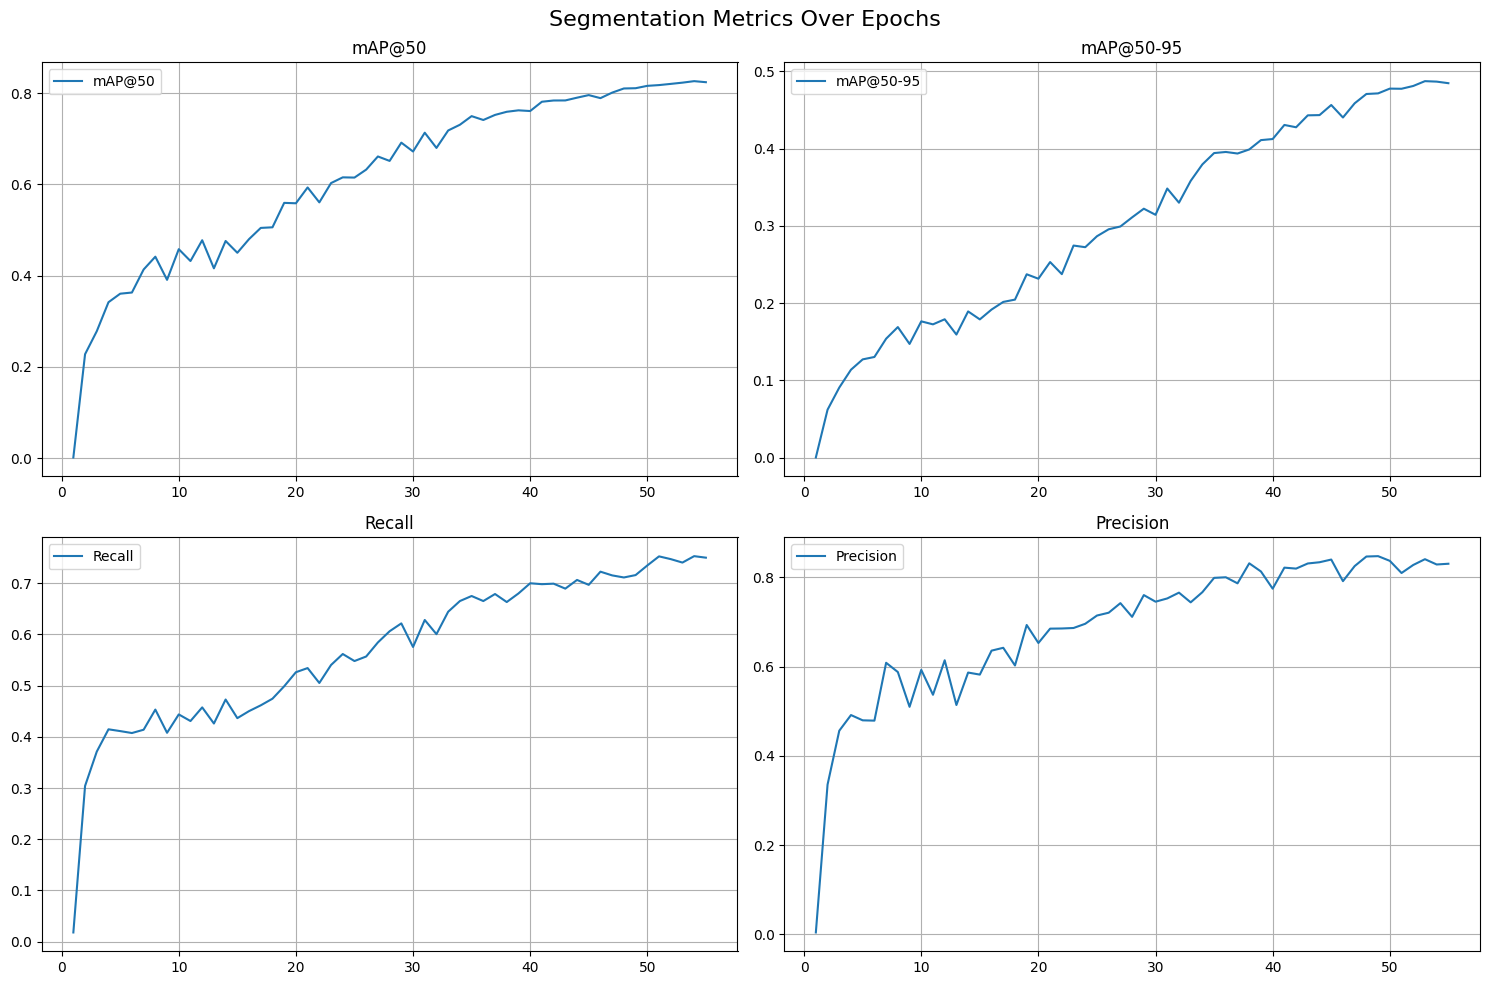

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

results_csv_path = "/content/runs/segment/FallenTrees_Project/yolov8s_seg_fallen2/results.csv"

if not os.path.exists(results_csv_path):
    print(f"Error: results.csv not found at {results_csv_path}")
else:
    df_results = pd.read_csv(results_csv_path)
    df_results.columns = df_results.columns.str.strip()

    epochs = df_results['epoch']

    map50 = df_results['metrics/mAP50(M)']
    map50_95 = df_results['metrics/mAP50-95(M)']
    recall = df_results['metrics/recall(M)']
    precision = df_results['metrics/precision(M)']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Segmentation Metrics Over Epochs', fontsize=16)

    axes[0, 0].plot(epochs, map50, label='mAP@50')
    axes[0, 0].set_title('mAP@50')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(epochs, map50_95, label='mAP@50-95')
    axes[0, 1].set_title('mAP@50-95')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(epochs, recall, label='Recall')
    axes[1, 0].set_title('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(epochs, precision, label='Precision')
    axes[1, 1].set_title('Precision')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

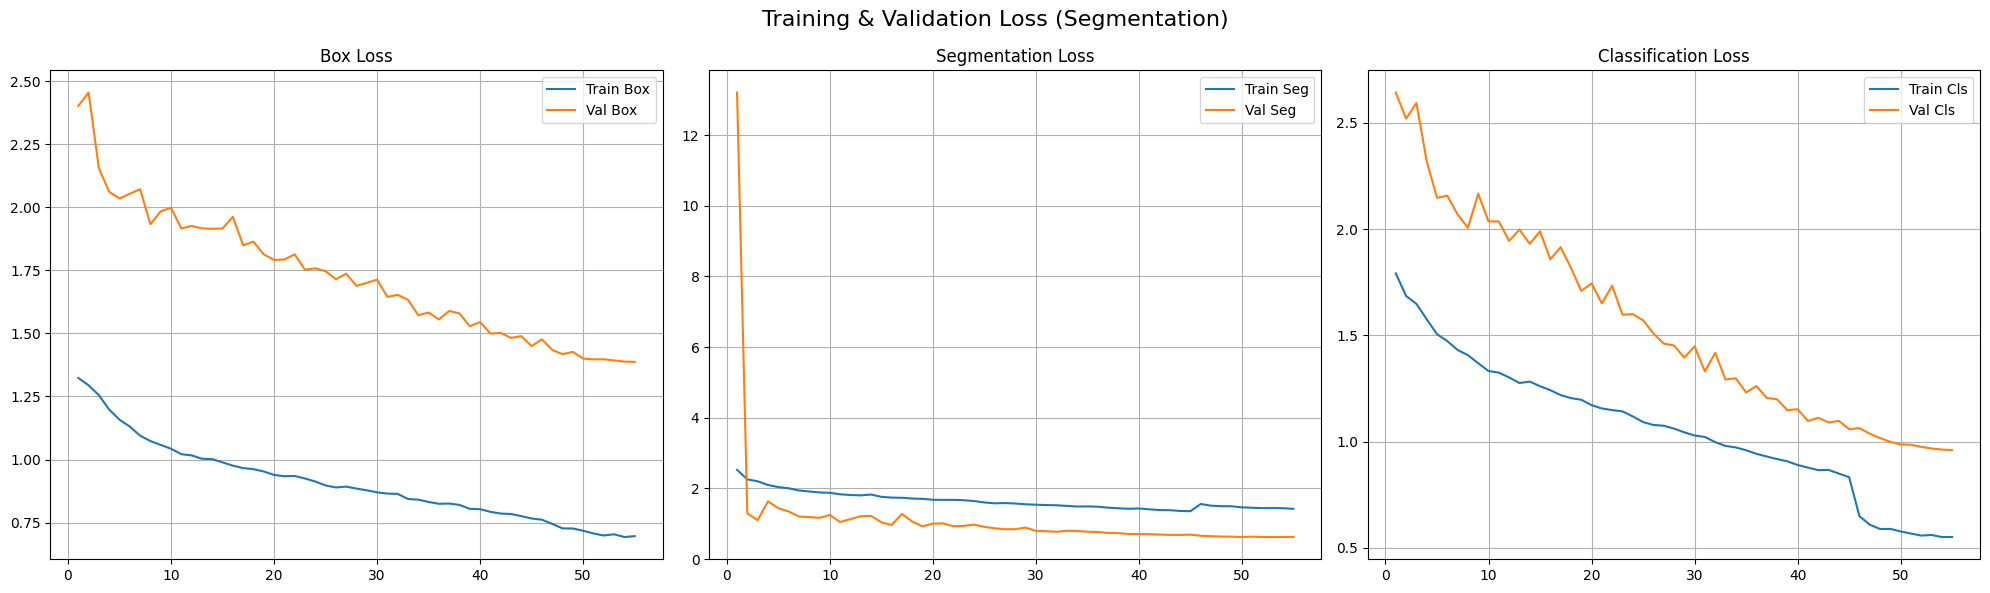

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

results_csv_path = "/content/runs/segment/FallenTrees_Project/yolov8s_seg_fallen2/results.csv"

if not os.path.exists(results_csv_path):
    print(f"Error: results.csv not found at {results_csv_path}")
else:
    df_results = pd.read_csv(results_csv_path, skipinitialspace=True)
    df_results.columns = df_results.columns.str.strip()

    epochs = df_results['epoch']

    train_box = df_results['train/box_loss']
    val_box = df_results['val/box_loss']

    train_seg = df_results['train/seg_loss']
    val_seg = df_results['val/seg_loss']

    train_cls = df_results['train/cls_loss']
    val_cls = df_results['val/cls_loss']

    dfl_exists = 'train/dfl_loss' in df_results.columns

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Training & Validation Loss (Segmentation)', fontsize=16)

    axes[0].plot(epochs, train_box, label='Train Box')
    axes[0].plot(epochs, val_box, label='Val Box')
    axes[0].set_title('Box Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, train_seg, label='Train Seg')
    axes[1].plot(epochs, val_seg, label='Val Seg')
    axes[1].set_title('Segmentation Loss')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(epochs, train_cls, label='Train Cls')
    axes[2].plot(epochs, val_cls, label='Val Cls')
    axes[2].set_title('Classification Loss')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()